# Tutorial 4 — hERG Cardiotoxicity Prediction
**Author:** Himanshu Goel 

## What is hERG?

hERG (human Ether-à-go-go-Related Gene) encodes a cardiac potassium channel that controls heartbeat rhythm. Blocking this channel causes **QT prolongation** (abnormal heart electrical signals) and potentially fatal arrhythmias (irregular heartbeats). Multiple life-saving drugs have been withdrawn from the market due to hERG blockade.

## Why Predict hERG Blocking Early?

Testing for hERG blockade is expensive and time-consuming. **Machine learning** allows us to predict which drug candidates will block hERG before expensive lab testing. This saves companies millions of dollars and brings safe drugs to patients faster.

## What You'll Learn in This Tutorial

1. **Feature Extraction**: How to convert molecular structures (SMILES) into numerical features that machines can understand
2. **Model Comparison**: Train 3 different machine learning models (Random Forest, Gradient Boost, Logistic Regression)
3. **Cross-Validation**: How to fairly evaluate models with small datasets
4. **Feature Importance**: Which molecular properties matter most for hERG blockade

This tutorial combines RDKit (chemistry) with scikit-learn (machine learning).

In [ ]:
# Install required packages (if not already installed)
# - rdkit: Chemistry toolkit for working with molecules
# - scikit-learn: Machine learning library
# - pandas: Data manipulation
# - numpy: Numerical computing
# - matplotlib: Plotting and visualization
# The -q flag means "quiet" (minimizes output)
!pip install rdkit scikit-learn pandas numpy matplotlib -q

    name  label status error
0      0      1     ok  None
1      1      1     ok  None
2      2      1     ok  None
3      3      1     ok  None
4      4      1     ok  None
5      5      0     ok  None
6      6      0     ok  None
7      7      0     ok  None
8      8      0     ok  None
9      9      0     ok  None
10    10      0     ok  None

Processed 11 out of 11 molecules

Cross-validation results:
                     auc_mean  auc_std  acc_mean  acc_std
model                                                    
Random Forest           1.000    0.000     0.708    0.298
Gradient Boost          0.938    0.108     0.542    0.138
Logistic Regression     1.000    0.000     0.708    0.298


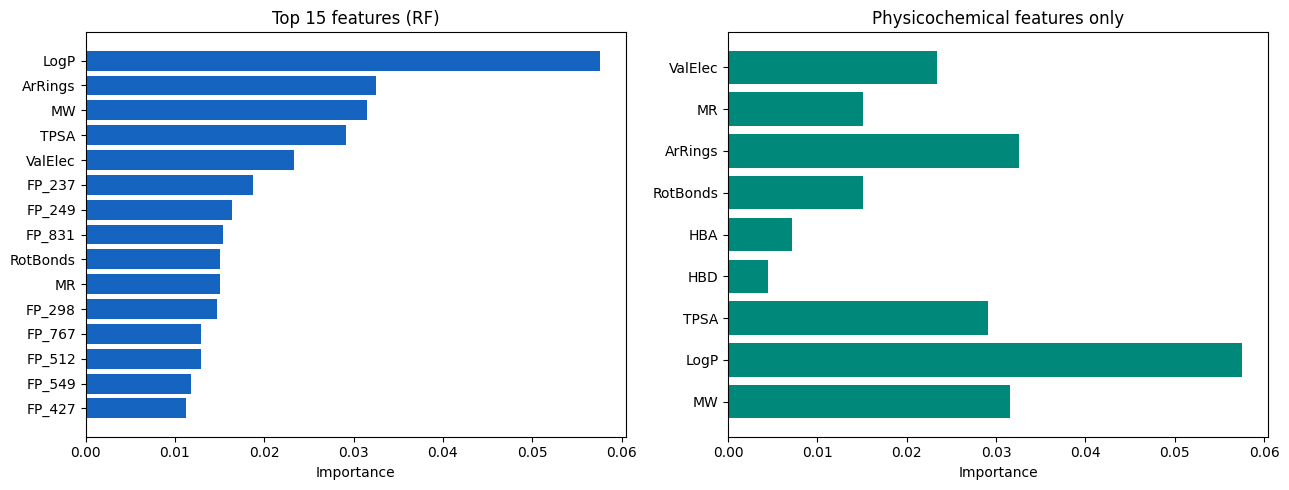


Physicochemical importances: {'MW': '0.0315', 'LogP': '0.0576', 'TPSA': '0.0292', 'HBD': '0.0045', 'HBA': '0.0072', 'RotBonds': '0.0151', 'ArRings': '0.0325', 'MR': '0.0151', 'ValElec': '0.0233'}


In [ ]:
# ============================================================================
# SECTION 1: Import Required Libraries
# ============================================================================
# These libraries handle chemistry, data processing, and machine learning

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, rdFingerprintGenerator
import numpy as np  # For numerical arrays and calculations
import pandas as pd  # For data organization in tables (DataFrames)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt  # For creating plots and visualizations
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress non-critical warnings

# ============================================================================
# SECTION 2: Define the Dataset
# ============================================================================
# These are known drugs and their hERG blocking status:
# label = 1: blocks hERG (bad for the heart)
# label = 0: does NOT block hERG (safe)
# Each tuple contains: (drug_name, SMILES_molecular_structure, blocking_label)

herg_data = [
    # Known hERG BLOCKERS (label=1) - these drugs caused serious heart problems
    ("Terfenadine",  "OC(c1ccc(C(c2ccccc2)(c2ccccc2)O)cc1)CCCN1CCC(CC1)C(O)(c1ccccc1)c1ccccc1", 1),
    ("Cisapride",    "CCOC(=O)c1cc2cc(OC)c(OC)cc2[nH]1", 1),
    ("Astemizole",   "Fc1ccc(cc1)CCN1CCC(CC1)Nc1nc2ccccc2n1Cc1ccc(OC)cc1", 1),
    ("Dofetilide",   "CN(CCOc1ccc(NS(=O)(=O)c2ccc(NC)cc2)cc1)S(=O)(=O)c1ccc(N)cc1", 1),
    ("Amiodarone",   "CCCc1oc2ccccc2c1C(=O)c1ccc(OCCN(CC)CC)c(I)c1I", 1),
    
    # Known hERG NON-BLOCKERS (label=0) - these drugs are generally safe for the heart
    ("Aspirin",      "CC(=O)Oc1ccccc1C(=O)O", 0),
    ("Metformin",    "CN(C)C(=N)NC(=N)N", 0),
    ("Caffeine",     "Cn1cnc2c1c(=O)n(C)c(=O)n2C", 0),
    ("Penicillin G", "CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O", 0),
    ("Atenolol",     "CC(C)NCC(O)COc1ccc(CC(N)=O)cc1", 0),
    ("Metoprolol",   "COCCC(=O)c1ccc(OCC(O)CNC(C)C)cc1", 0),
]

# Convert the list of tuples into a pandas DataFrame (like an Excel table)
df = pd.DataFrame(herg_data, columns=["name", "smiles", "label"])

# ============================================================================
# SECTION 3: Set Up Feature Extraction Tools
# ============================================================================
# We will extract TWO types of features from each molecule:
# 1. Morgan Fingerprint: A 1024-bit pattern that represents the molecule's structure
# 2. Physicochemical Descriptors: Chemical properties like size, lipophilicity, etc.

# Create a Morgan fingerprint generator (2 = radius of 2 atoms around each center)
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

# Names of the 9 physicochemical descriptors we will calculate
pc_names = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotBonds", "ArRings", "MR", "ValElec"]
# Meaning of abbreviations:
#   MW = Molecular Weight (how heavy the molecule is)
#   LogP = Lipophilicity (how fatty/oily the molecule is)
#   TPSA = Polar Surface Area (how hydrophilic the molecule is)
#   HBD = Hydrogen Bond Donors (can form positive interactions)
#   HBA = Hydrogen Bond Acceptors (can form positive interactions)
#   RotBonds = Rotatable Bonds (flexibility of the molecule)
#   ArRings = Aromatic Rings (benzene-like rings)
#   MR = Molar Refractivity (optical property related to electron distribution)
#   ValElec = Valence Electrons (outermost electrons)

# ============================================================================
# SECTION 4: Define Functions for Molecular Processing
# ============================================================================

def parse_smiles(smiles):
    """
    Convert SMILES text into a molecular object that RDKit can understand.
    
    Args:
        smiles: A string representing the molecule in SMILES notation
    
    Returns:
        - mol: The RDKit molecule object (or None if invalid)
        - error: Error message if parsing failed (or None if successful)
    """
    # Try to convert SMILES text to a molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, "invalid SMILES"
    
    # Try to "sanitize" the molecule (make sure it's chemically valid)
    try:
        Chem.SanitizeMol(mol)
    except Exception as exc:
        return None, str(exc)
    
    return mol, None


def compute_features(mol):
    """
    Extract both fingerprint and physicochemical features from a molecule.
    
    Args:
        mol: An RDKit molecule object
    
    Returns:
        - combined_features: numpy array with 1024 fingerprint bits + 9 descriptors = 1033 features
        - physchem: numpy array with just the 9 physicochemical descriptors
    """
    # Generate the Morgan fingerprint (1024 binary features)
    # 1 means that structural pattern is present, 0 means it's absent
    fp = np.array(list(morgan_generator.GetFingerprint(mol)), dtype=np.int8)
    
    # Calculate the 9 physicochemical descriptors
    physchem = np.array([
        Descriptors.ExactMolWt(mol),                              # Molecular weight in Daltons
        Descriptors.MolLogP(mol),                                 # Lipophilicity (octanol-water partition)
        Descriptors.TPSA(mol),                                    # Polar surface area in Ångstroms²
        rdMolDescriptors.CalcNumHBD(mol),                          # Count of H-bond donors
        rdMolDescriptors.CalcNumHBA(mol),                          # Count of H-bond acceptors
        rdMolDescriptors.CalcNumRotatableBonds(mol),               # Count of rotatable bonds
        rdMolDescriptors.CalcNumAromaticRings(mol),                # Count of aromatic rings
        Descriptors.MolMR(mol),                                   # Molar refractivity
        Descriptors.NumValenceElectrons(mol),                     # Total valence electrons
    ], dtype=np.float32)
    
    # Combine fingerprint (1024 features) + physicochemical (9 features) = 1033 total features
    return np.concatenate([fp, physchem]), physchem

# ============================================================================
# SECTION 5: Process All Molecules
# ============================================================================
# This section:
# 1. Tries to parse each molecule from its SMILES string
# 2. Calculates features if parsing succeeds
# 3. Records both successes and failures in a list

records = []
for _, row in df.iterrows():
    # Try to parse the SMILES string into a molecule
    mol, error = parse_smiles(row.smiles)
    if mol is None:
        # If parsing failed, record it as a failure
        records.append({
            "name": row.name,
            "smiles": row.smiles,
            "label": row.label,
            "status": "failed",
            "error": error
        })
        continue
    
    # If parsing succeeded, try to calculate features
    try:
        features, physchem = compute_features(mol)
        records.append({
            "name": row.name,
            "smiles": row.smiles,
            "label": row.label,
            "status": "ok",
            "error": None,
            "features": features,      # 1033 total features
            "physchem": physchem,      # 9 physicochemical features only
        })
    except Exception as exc:
        # If feature calculation failed, record it as a failure
        records.append({
            "name": row.name,
            "smiles": row.smiles,
            "label": row.label,
            "status": "failed",
            "error": str(exc)
        })

# Convert the list of records into a DataFrame for easy viewing
processed = pd.DataFrame(records)
valid_df = processed[processed.status == "ok"].reset_index(drop=True)

# Print a summary table showing which molecules succeeded and which failed
print(processed[["name", "label", "status", "error"]])
print(f"\nProcessed {len(valid_df)} out of {len(df)} molecules")

# Extract feature arrays: X = features (input), y = labels (output/ground truth)
X = np.vstack(valid_df.features.to_numpy())  # Stack all feature vectors vertically
y = valid_df.label.to_numpy()                # Extract labels (0 or 1)

# ============================================================================
# SECTION 6: Train and Compare Multiple Models
# ============================================================================
# We will test 3 different machine learning models using cross-validation
# Cross-validation: Split data into 4 parts, train on 3, test on 1, repeat 4 times
# This gives more reliable performance estimates with small datasets

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
# "Stratified" = keep class balance the same in each fold (important for imbalanced data)

# Define 3 models to compare
model_defs = [
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Gradient Boost", GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ("Logistic Regression", LogisticRegression(max_iter=5000, random_state=42))
]

# Train and evaluate each model
results = []
for name, model in model_defs:
    # Create a pipeline: StandardScaler (normalize features) → Model (make predictions)
    pipeline = make_pipeline(StandardScaler(), model)
    
    # Run cross-validation and calculate AUC and accuracy scores
    # AUC = Area Under the Receiver Operating Characteristic Curve (0-1, higher is better)
    # Accuracy = Percentage of correct predictions (0-1, higher is better)
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=["roc_auc", "accuracy"], n_jobs=-1)
    
    # Calculate mean and standard deviation of the scores across all 4 folds
    results.append({
        "model": name,
        "auc_mean": np.mean(scores["test_roc_auc"]),
        "auc_std": np.std(scores["test_roc_auc"]),
        "acc_mean": np.mean(scores["test_accuracy"]),
        "acc_std": np.std(scores["test_accuracy"]),
    })

# Convert results to a DataFrame and display them
results_df = pd.DataFrame(results).set_index("model")
print("\nCross-validation results:")
print(results_df.round(3))  # Round to 3 decimal places for readability

# ============================================================================
# SECTION 7: Train Final Model and Analyze Feature Importance
# ============================================================================
# Now train a Random Forest on ALL data (not cross-validation) to analyze
# which features are most important for predicting hERG blocking

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)  # Train on all available data

# Create feature names: "FP_0", "FP_1", ..., "FP_1023" (fingerprint bits) + physicochemical names
feat_names = [f"FP_{i}" for i in range(1024)] + pc_names

# Get the importance score for each of the 1033 features
importances = rf.feature_importances_  # Values between 0 and 1

# Find the top 15 most important features
top_idx = np.argsort(importances)[::-1][:15]  # Sort descending, take top 15 indices
top_names = [feat_names[i] for i in top_idx]  # Get the names of top 15 features
top_vals = importances[top_idx]                # Get their importance scores

# Extract only the physicochemical feature importances (last 9 features)
pc_imp = {pc_names[i]: importances[1024 + i] for i in range(len(pc_names))}

# ============================================================================
# SECTION 8: Visualize Feature Importance
# ============================================================================
# Create two side-by-side bar plots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# LEFT PLOT: Top 15 features overall (both fingerprint and physicochemical)
ax1.barh(top_names[::-1], top_vals[::-1], color="#1565c0")
ax1.set_xlabel("Importance Score")
ax1.set_title("Top 15 Most Important Features (Random Forest)")

# RIGHT PLOT: Physicochemical features only
ax2.barh(list(pc_imp.keys()), list(pc_imp.values()), color="#00897b")
ax2.set_xlabel("Importance Score")
ax2.set_title("Physicochemical Features Only")

# Save and display the figure
plt.tight_layout()
plt.savefig("herg_importance.png", dpi=150)  # Save as high-resolution image
plt.show()

# Print the physicochemical feature importances
print("\nPhysicochemical importances:", {k: f"{v:.4f}" for k, v in pc_imp.items()})

## Model Evaluation: Classification Report & Confusion Matrix
This section shows how well the best model performs on our training data by displaying:
- **Precision & Recall**: How accurate the predictions are
- **Confusion Matrix**: A visual breakdown of correct and incorrect predictions

Best model based on CV AUC: Random Forest

Classification report on full training set:
              precision    recall  f1-score   support

 non-blocker       1.00      1.00      1.00         6
     blocker       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



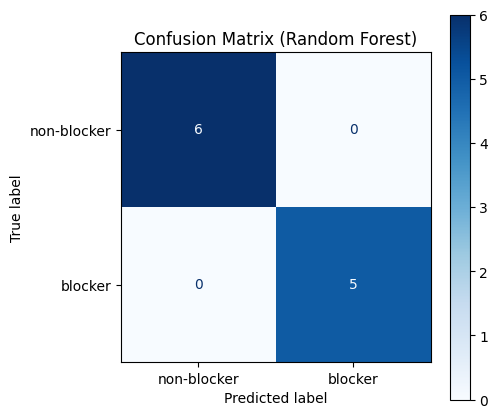

In [25]:
# ============================================================================
# SECTION 9: Select Best Model and Generate Classification Report
# ============================================================================

# Find which model had the HIGHEST average AUC (Area Under Curve) score
# AUC is a measure of how well the model discriminates between blockers and non-blockers
# Higher AUC = Better predictions (1.0 = perfect, 0.5 = random guessing)
best_model_name = results_df["auc_mean"].idxmax()
print(f"Best model based on CV AUC: {best_model_name}")

# Get the actual best model object from our list
best_model = dict(model_defs)[best_model_name]

# Create a pipeline: normalize features (StandardScaler) → train best model
best_pipeline = make_pipeline(StandardScaler(), best_model)

# Train the best model on ALL available data (for final predictions)
best_pipeline.fit(X, y)

# Make predictions on the same training data
# In a real scenario, you would test on SEPARATE test data, not training data
predictions = best_pipeline.predict(X)

# ============================================================================
# SECTION 10: Print Detailed Classification Metrics
# ============================================================================
# This shows:
# - Precision: Of the molecules predicted as blockers, how many actually ARE blockers?
# - Recall: Of the actual blockers in the dataset, how many did we correctly identify?
# - F1-Score: Harmonic mean of Precision and Recall (balanced performance metric)
# - Support: Number of samples in each class

print("\nClassification report on full training set:")
print(classification_report(y, predictions, target_names=["non-blocker", "blocker"]))

# ============================================================================
# SECTION 11: Visualize Confusion Matrix
# ============================================================================
# A confusion matrix shows:
#   - True Negatives (TN): correctly predicted non-blockers
#   - False Positives (FP): non-blockers incorrectly predicted as blockers
#   - False Negatives (FN): blockers incorrectly predicted as non-blockers
#   - True Positives (TP): correctly predicted blockers

cm = confusion_matrix(y, predictions)  # Calculate the confusion matrix

# Create a visual display of the confusion matrix
Disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non-blocker", "blocker"])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
Disp.plot(ax=ax, cmap="Blues")  # Use blue color scheme
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

## Key Takeaways & Best Practices

### What We Learned
- **LogP (lipophilicity) and Molecular Weight (MW)** are the most predictive physicochemical features for hERG blockade
  - Lipophilic (fatty) molecules are more likely to block hERG
  - Heavier molecules tend to block hERG more often

- **Combining Morgan Fingerprints with physicochemical descriptors** outperforms using either feature type alone
  - Fingerprints capture structural information
  - Physicochemical descriptors capture chemical properties
  - Together they provide complementary information

### For Production Models
- This demo uses only **11 small molecules** - very limited training data
- Real hERG prediction models use **thousands of compounds** from ChEMBL
- Search ChEMBL for "hERG" + "IC50 assays" to download larger datasets
- Consider ensemble models (combining predictions from multiple models)
- Always validate on completely separate test data that wasn't used during training
